# Лабораторная 2: Классификация цветов автомобилей (DVM)

## Цели

1. Обучить классификатор **ResNet18** с нуля на датасете DVM (фронтальные изображения).
2. Взять тот же **ResNet18, предобученный на ImageNet**, и дообучить его на тех же данных.
3. Сравнить качество (F1_macro > 0.8) и сделать вывод.

**Датасет:** DVM — https://deepvisualmarketing.github.io/ (используются только фронтальные ракурсы).

In [1]:
import os
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from PIL import Image

from sklearn.metrics import f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"torch: {torch.__version__}, torchvision: {torchvision.__version__}")

Using device: cuda
torch: 2.5.1+cu121, torchvision: 0.20.1+cu121


## Глобальные гиперпараметры

In [3]:
DATA_ROOT = Path('/home/greg/git/uni/cv/Lab1/extracted_data/confirmed_fronts')
WEIGHTS_DIR = Path('/home/greg/git/uni/advanced-ml/Lab2')

IMG_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = 4

EPOCHS = 15
LR_SCRATCH = 1e-3
LR_FT = 1e-4

VAL_RATIO = 0.2
MIN_CLASS_SAMPLES = 500     # drop colours with fewer than this many images
MAX_PER_CLASS = 3000        # cap each kept class to at most this many images
DROP_LABELS = {'Unlisted', 'Multicolour'}  # not real colours

# ImageNet normalisation — required for pretrained weights, reasonable for scratch
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

---
## Раздел 1: Данные

Имена файлов имеют формат `Make$$Model$$Year$$Color$$...$$image_N.jpg` — цвет кузова находится на позиции 3 после split по `$$`.

In [4]:
# Scan filesystem, parse (path, color) pairs
def scan_dvm(data_root):
    records = []
    for path in data_root.rglob('*.jpg'):
        parts = path.name.split('$$')
        if len(parts) < 4:
            continue
        color = parts[3]
        records.append((path, color))
    return records

all_records = scan_dvm(DATA_ROOT)
raw_counter = Counter(c for _, c in all_records)

print(f"Total images: {len(all_records)}")
print(f"Distinct raw colour labels: {len(raw_counter)}")
for colour, n in raw_counter.most_common():
    print(f"  {colour:<14s} {n:>6d}")

Total images: 61827
Distinct raw colour labels: 23
  Black           14317
  Grey             9474
  White            9395
  Blue             8483
  Silver           7770
  Red              6095
  Unlisted         1516
  Brown             911
  Green             777
  Yellow            667
  Beige             600
  Orange            559
  Purple            362
  Bronze            329
  Gold              217
  Multicolour       196
  Pink               87
  Maroon             26
  Turquoise          26
  Burgundy            9
  Magenta             9
  Navy                1
  Indigo              1


In [5]:
# Filter: drop non-colour labels and rare classes
kept_labels = sorted(
    c for c, n in raw_counter.items()
    if n >= MIN_CLASS_SAMPLES and c not in DROP_LABELS
)
print(f"Kept {len(kept_labels)} classes: {kept_labels}")

filtered = [(p, c) for p, c in all_records if c in set(kept_labels)]
print(f"Images after class filtering: {len(filtered)}")

Kept 11 classes: ['Beige', 'Black', 'Blue', 'Brown', 'Green', 'Grey', 'Orange', 'Red', 'Silver', 'White', 'Yellow']
Images after class filtering: 59048


In [6]:
# Cap each class to MAX_PER_CLASS with a seeded sample
rng = random.Random(SEED)
by_class = defaultdict(list)
for p, c in filtered:
    by_class[c].append(p)

CLASS_NAMES = sorted(by_class.keys())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

capped_records = []
for c in CLASS_NAMES:
    paths = by_class[c]
    rng.shuffle(paths)
    keep = paths[:MAX_PER_CLASS]
    capped_records.extend((p, CLASS_TO_IDX[c]) for p in keep)

rng.shuffle(capped_records)
print(f"Final dataset: {len(capped_records)} images, {len(CLASS_NAMES)} classes")
final_counts = Counter(c for c in CLASS_NAMES for _ in range(min(len(by_class[c]), MAX_PER_CLASS)))
for c in CLASS_NAMES:
    print(f"  {c:<8s} {final_counts[c]:>5d}")

Final dataset: 21514 images, 11 classes
  Beige      600
  Black     3000
  Blue      3000
  Brown      911
  Green      777
  Grey      3000
  Orange     559
  Red       3000
  Silver    3000
  White     3000
  Yellow     667


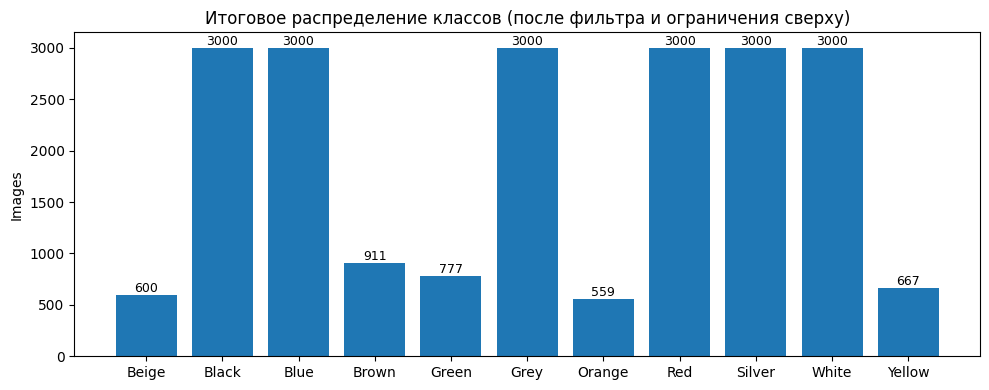

In [7]:
# Class-count bar chart
fig, ax = plt.subplots(figsize=(10, 4))
counts = [final_counts[c] for c in CLASS_NAMES]
bars = ax.bar(CLASS_NAMES, counts, color='#1f77b4')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Images')
ax.set_title('Итоговое распределение классов (после фильтра и ограничения сверху)')
plt.tight_layout()
plt.show()

In [8]:
class CarColorDataset(Dataset):
    """DVM frontal-image dataset returning (image_tensor, class_idx)."""

    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        path, label = self.records[i]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        return img, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def make_dataloaders(records, batch_size=BATCH_SIZE, val_ratio=VAL_RATIO, seed=SEED):
    """Stratified-ish split via random_split on the full list, returns (train_loader, val_loader)."""
    n_total = len(records)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    g = torch.Generator().manual_seed(seed)
    train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=g)

    train_records = [records[i] for i in train_idx]
    val_records = [records[i] for i in val_idx]

    train_ds = CarColorDataset(train_records, train_transform)
    val_ds = CarColorDataset(val_records, val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              drop_last=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader


train_loader, val_loader = make_dataloaders(capped_records)
print(f"Train batches: {len(train_loader)}  (≈{len(train_loader) * BATCH_SIZE} imgs)")
print(f"Val batches:   {len(val_loader)}  (≈{len(val_loader.dataset)} imgs)")

Train batches: 268  (≈17152 imgs)
Val batches:   68  (≈4302 imgs)


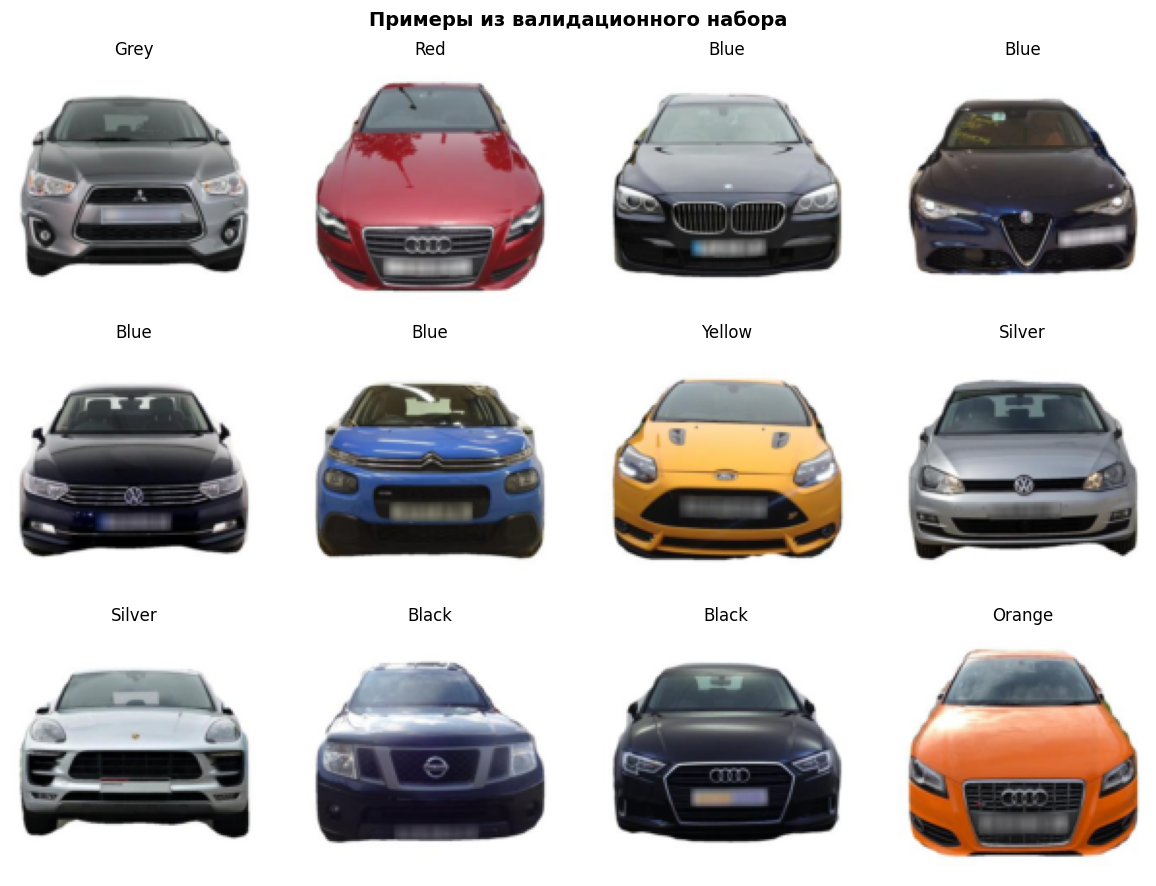

In [9]:
# Sample grid — sanity-check labels
def denormalize(img_t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_t * std + mean).clamp(0, 1)


xs, ys = next(iter(val_loader))
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, ax in enumerate(axes.flat):
    img = denormalize(xs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[ys[i].item()])
    ax.axis('off')
fig.suptitle('Примеры из валидационного набора', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Раздел 2: Модель — ResNet18

Стандартная архитектура ResNet18: стартовая свёртка + 4 стадии по 2 блока BasicBlock, за ними global average pooling и линейный классификатор. Идентична той, что есть в `torchvision`, но реализована вручную, чтобы можно было сравнить с предобученной.

In [10]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        self.layer1 = self._make_stage(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_stage(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_stage(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_stage(256, 512, blocks=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)

    @staticmethod
    def _make_stage(in_c, out_c, blocks, stride):
        layers = [BasicBlock(in_c, out_c, stride=stride)]
        for _ in range(blocks - 1):
            layers.append(BasicBlock(out_c, out_c, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.fc(x)


# Quick shape check
_probe = ResNet18(num_classes=len(CLASS_NAMES)).to(device)
with torch.no_grad():
    _out = _probe(torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device))
print(f"Output shape: {tuple(_out.shape)}  (expected: (2, {len(CLASS_NAMES)}))")
print(f"Parameters: {sum(p.numel() for p in _probe.parameters()):,}")
del _probe

Output shape: (2, 11)  (expected: (2, 11))
Parameters: 11,182,155


In [11]:
def load_pretrained_resnet18(num_classes):
    """ResNet18 pre-trained on ImageNet with the classification head replaced."""
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


_pre = load_pretrained_resnet18(len(CLASS_NAMES)).to(device)
with torch.no_grad():
    _out = _pre(torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device))
print(f"Pretrained output shape: {tuple(_out.shape)}")
print(f"Parameters: {sum(p.numel() for p in _pre.parameters()):,}")
del _pre

Pretrained output shape: (2, 11)
Parameters: 11,182,155


---
## Раздел 3: Обучение

Структура повторяет Lab1: отдельные функции `train_one_epoch`, `evaluate`, `run_experiment`. Для классификации возвращаем loss, accuracy и (на валидации) F1_macro. Перед запуском обучения проверяется наличие файла с весами — если веса уже есть, обучение пропускается.

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n_correct, n_samples = 0.0, 0, 0
    for X_batch, Y_batch in loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, Y_batch)
        loss.backward()
        optimizer.step()
        bs = X_batch.size(0)
        total_loss += loss.item() * bs
        n_correct += (logits.argmax(1) == Y_batch).sum().item()
        n_samples += bs
    return total_loss / n_samples, n_correct / n_samples


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n_correct, n_samples = 0.0, 0, 0
    all_y, all_p = [], []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, Y_batch)
            bs = X_batch.size(0)
            total_loss += loss.item() * bs
            preds = logits.argmax(1)
            n_correct += (preds == Y_batch).sum().item()
            n_samples += bs
            all_y.append(Y_batch.cpu().numpy())
            all_p.append(preds.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    return total_loss / n_samples, n_correct / n_samples, f1_macro, y_true, y_pred


def run_experiment(model_factory, weights_path, lr, epochs=EPOCHS, seed=SEED,
                   train_loader=train_loader, val_loader=val_loader):
    """Build + train (or load cached weights), return (model, history)."""
    torch.manual_seed(seed)
    model = model_factory(len(CLASS_NAMES)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

    if weights_path.exists():
        print(f"Loading cached weights from {weights_path.name} (skip training).")
        model.load_state_dict(torch.load(weights_path, map_location=device))
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f"  val loss={val_loss:.4f}  val acc={val_acc:.4f}  val F1_macro={val_f1:.4f}")
        return model, history

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f"  epoch {epoch:02d}/{epochs}  "
              f"train loss={tr_loss:.4f} acc={tr_acc:.4f}  |  "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} F1={val_f1:.4f}")

    torch.save(model.state_dict(), weights_path)
    print(f"Saved weights -> {weights_path}")
    return model, history

---
## Часть 1: ResNet18 с нуля (без предобучения)

In [13]:
scratch_model, scratch_hist = run_experiment(
    model_factory=ResNet18,
    weights_path=WEIGHTS_DIR / 'resnet_scratch.pth',
    lr=LR_SCRATCH,
)

Loading cached weights from resnet_scratch.pth (skip training).


/tmp/ipykernel_346170/3616001792.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


  val loss=0.6280  val acc=0.8224  val F1_macro=0.7874


  epoch 02/15  train loss=0.8273 acc=0.7154  |  val loss=0.9371 acc=0.6629 F1=0.6199


  epoch 03/15  train loss=0.7207 acc=0.7540  |  val loss=0.8113 acc=0.7278 F1=0.6679


...

  epoch 11/15  train loss=0.3688 acc=0.8755  |  val loss=0.6109 acc=0.8217 F1=0.7663


  epoch 12/15  train loss=0.3466 acc=0.8844  |  val loss=0.6553 acc=0.8054 F1=0.7470


  epoch 13/15  train loss=0.3094 acc=0.8932  |  val loss=0.6674 acc=0.7968 F1=0.7553


  epoch 14/15  train loss=0.2770 acc=0.9044  |  val loss=0.7707 acc=0.7731 F1=0.7336


  epoch 15/15  train loss=0.2435 acc=0.9158  |  val loss=0.6280 acc=0.8224 F1=0.7874
Saved weights -> /home/greg/git/uni/advanced-ml/Lab2/resnet_scratch.pth


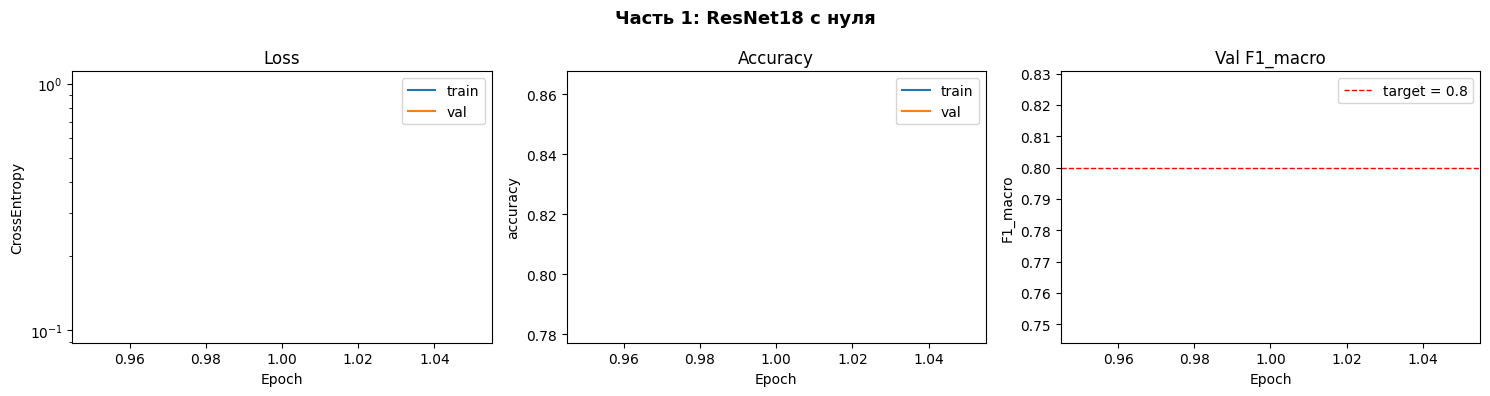

In [14]:
# Loss / accuracy / F1 curves
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    train_x = range(1, len(history['train_loss']) + 1)
    val_x   = range(1, len(history['val_loss']) + 1)

    axes[0].plot(train_x, history['train_loss'], label='train', color='#1f77b4')
    axes[0].plot(val_x,   history['val_loss'],   label='val',   color='#ff7f0e')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CrossEntropy')
    axes[0].set_yscale('log'); axes[0].legend()

    axes[1].plot(train_x, history['train_acc'], label='train', color='#1f77b4')
    axes[1].plot(val_x,   history['val_acc'],   label='val',   color='#ff7f0e')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('accuracy')
    axes[1].legend()

    axes[2].plot(val_x, history['val_f1'], color='#2ca02c')
    axes[2].axhline(0.8, color='red', linestyle='--', linewidth=1, label='target = 0.8')
    axes[2].set_title('Val F1_macro')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1_macro')
    axes[2].legend()

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_training_curves(scratch_hist, 'Часть 1: ResNet18 с нуля')

In [15]:
# Classification report + confusion matrix on validation
criterion = nn.CrossEntropyLoss()
_, scratch_acc, scratch_f1, scratch_y_true, scratch_y_pred = evaluate(
    scratch_model, val_loader, criterion, device
)

print(f"Scratch ResNet18 — val accuracy: {scratch_acc:.4f}, F1_macro: {scratch_f1:.4f}\n")
print(classification_report(scratch_y_true, scratch_y_pred,
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

Scratch ResNet18 — val accuracy: 0.8224, F1_macro: 0.7874

              precision    recall  f1-score   support

       Beige      0.765     0.489     0.596       133
       Black      0.766     0.855     0.808       559
        Blue      0.801     0.897     0.846       583
       Brown      0.699     0.610     0.651       164
       Green      0.755     0.688     0.720       157
        Grey      0.746     0.705     0.724       599
      Orange      0.922     0.607     0.732       117
         Red      0.934     0.972     0.953       610
      Silver      0.789     0.786     0.788       632
       White      0.904     0.906     0.905       594
      Yellow      0.947     0.929     0.938       154

    accuracy                          0.822      4302
   macro avg      0.821     0.768     0.787      4302
weighted avg      0.822     0.822     0.819      4302



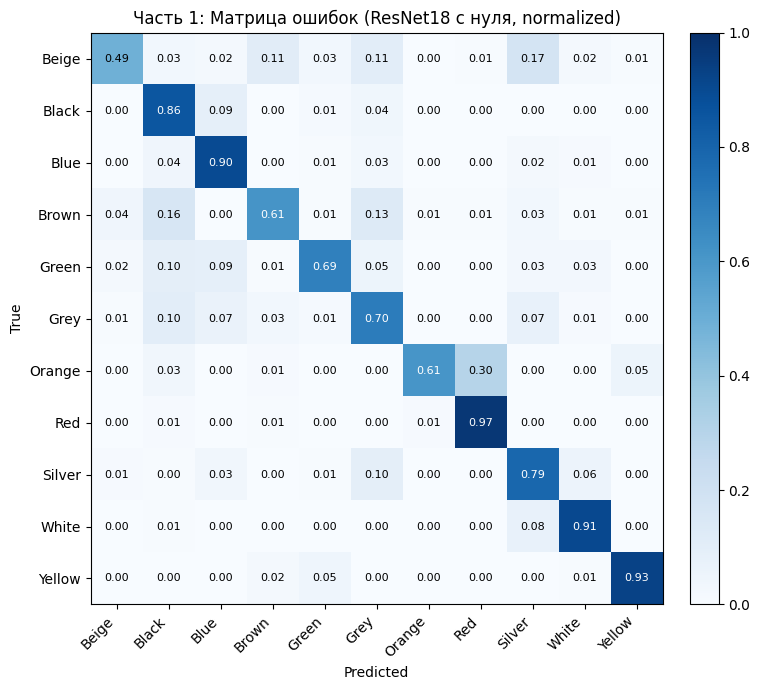

In [16]:
def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            v = cm_norm[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v > 0.5 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


plot_confusion(scratch_y_true, scratch_y_pred, CLASS_NAMES,
               'Часть 1: Матрица ошибок (ResNet18 с нуля, normalized)')

---
## Часть 1b: Улучшенная scratch-версия (чтобы перешагнуть 0.8)

Модель и данные — те же, но меняем рецепт обучения:

1. **Class-weighted CrossEntropy + label smoothing** (0.1). Веса ∝ 1/частота → напрямую боремся с низким recall у малых классов (Beige, Orange, Brown).
2. **AdamW (weight_decay=1e-4) + CosineAnnealingLR** вместо Adam без WD.
3. **Чуть более агрессивная аугментация**: `RandomResizedCrop(scale=0.75–1.0)` + `RandomAffine(±5°, shift 5%)` — цвет не трогаем.
4. **20 эпох** + **чекпоинт с лучшим val F1_macro** (не последний эпоха).
5. **TTA** на инференсе: усреднение логитов по оригиналу и горизонтальному флипу.

In [17]:
# --- Setup: augmented transform, new dataloaders with SAME split, class weights ---

train_transform_plus = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Re-build loaders using the IDENTICAL split (same records, same SEED → same indices)
n_total = len(capped_records)
n_val = int(n_total * VAL_RATIO)
n_train = n_total - n_val
g = torch.Generator().manual_seed(SEED)
_train_idx, _val_idx = random_split(range(n_total), [n_train, n_val], generator=g)

_train_records = [capped_records[i] for i in _train_idx]
_val_records = [capped_records[i] for i in _val_idx]

train_loader_plus = DataLoader(
    CarColorDataset(_train_records, train_transform_plus),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader_plus = DataLoader(
    CarColorDataset(_val_records, val_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

# Class weights (inverse frequency, normalised so mean ≈ 1)
_class_counts = np.array([final_counts[c] for c in CLASS_NAMES], dtype=np.float32)
class_weights = torch.tensor(_class_counts.mean() / _class_counts,
                             dtype=torch.float32, device=device)

print("Class weights (inv. freq):")
for c, w in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    print(f"  {c:<8s} {w:.3f}")

Class weights (inv. freq):
  Beige    3.260
  Black    0.652
  Blue     0.652
  Brown    2.147
  Green    2.517
  Grey     0.652
  Orange   3.499
  Red      0.652
  Silver   0.652
  White    0.652
  Yellow   2.932


In [18]:
# --- Training: AdamW + Cosine LR + weighted CE + label smoothing, keep best-F1 checkpoint ---

EPOCHS_PLUS = 20
LR_PLUS = 1e-3
WD_PLUS = 1e-4
CKPT_PATH_PLUS = WEIGHTS_DIR / 'resnet_scratch_plus.pt'

torch.manual_seed(SEED)
scratch_plus_model = ResNet18(len(CLASS_NAMES)).to(device)

if CKPT_PATH_PLUS.exists():
    print(f"Loading cached checkpoint from {CKPT_PATH_PLUS.name} (skip training).")
    ckpt = torch.load(CKPT_PATH_PLUS, map_location=device, weights_only=False)
    scratch_plus_model.load_state_dict(ckpt['state_dict'])
    scratch_plus_hist = ckpt['history']
    best_f1_plus = ckpt['best_val_f1']
    best_epoch_plus = ckpt['best_epoch']
    print(f"  best val F1_macro during training: {best_f1_plus:.4f} at epoch {best_epoch_plus}")
else:
    optimizer = optim.AdamW(scratch_plus_model.parameters(), lr=LR_PLUS, weight_decay=WD_PLUS)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PLUS)
    criterion_plus = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    scratch_plus_hist = {'train_loss': [], 'val_loss': [], 'train_acc': [],
                         'val_acc': [], 'val_f1': [], 'lr': []}
    best_f1_plus = -1.0
    best_epoch_plus = -1
    best_state = None

    for epoch in range(1, EPOCHS_PLUS + 1):
        tr_loss, tr_acc = train_one_epoch(
            scratch_plus_model, train_loader_plus, optimizer, criterion_plus, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(
            scratch_plus_model, val_loader_plus, criterion_plus, device)
        scheduler.step()

        scratch_plus_hist['train_loss'].append(tr_loss)
        scratch_plus_hist['val_loss'].append(val_loss)
        scratch_plus_hist['train_acc'].append(tr_acc)
        scratch_plus_hist['val_acc'].append(val_acc)
        scratch_plus_hist['val_f1'].append(val_f1)
        scratch_plus_hist['lr'].append(scheduler.get_last_lr()[0])

        is_best = val_f1 > best_f1_plus
        marker = '*' if is_best else ' '
        if is_best:
            best_f1_plus = val_f1
            best_epoch_plus = epoch
            best_state = {k: v.detach().cpu().clone()
                          for k, v in scratch_plus_model.state_dict().items()}

        print(f"  {marker} epoch {epoch:02d}/{EPOCHS_PLUS}  "
              f"train loss={tr_loss:.4f} acc={tr_acc:.4f}  |  "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} F1={val_f1:.4f}")

    # Restore best weights and save checkpoint
    scratch_plus_model.load_state_dict(best_state)
    torch.save({'state_dict': best_state,
                'history': scratch_plus_hist,
                'best_val_f1': best_f1_plus,
                'best_epoch': best_epoch_plus},
               CKPT_PATH_PLUS)
    print(f"\nBest val F1_macro during training: {best_f1_plus:.4f} (epoch {best_epoch_plus})")
    print(f"Saved checkpoint -> {CKPT_PATH_PLUS}")

Loading cached checkpoint from resnet_scratch_plus.pt (skip training).
  best val F1_macro during training: 0.8188 at epoch 18


  * epoch 03/20  train loss=1.5157 acc=0.6393  |  val loss=1.4293 acc=0.6771 F1=0.6489


    epoch 04/20  train loss=1.4409 acc=0.6835  |  val loss=1.4983 acc=0.6548 F1=0.5964


    epoch 05/20  train loss=1.3989 acc=0.7112  |  val loss=1.3976 acc=0.6741 F1=0.6474


  * epoch 06/20  train loss=1.3513 acc=0.7302  |  val loss=1.3889 acc=0.7513 F1=0.6946


...

  * epoch 16/20  train loss=1.0662 acc=0.8569  |  val loss=1.1512 acc=0.8254 F1=0.7984


  * epoch 17/20  train loss=1.0448 acc=0.8687  |  val loss=1.1409 acc=0.8338 F1=0.8126


  * epoch 18/20  train loss=1.0277 acc=0.8737  |  val loss=1.1311 acc=0.8422 F1=0.8188


    epoch 19/20  train loss=1.0115 acc=0.8800  |  val loss=1.1223 acc=0.8391 F1=0.8158


    epoch 20/20  train loss=1.0040 acc=0.8846  |  val loss=1.1245 acc=0.8389 F1=0.8164

Best val F1_macro during training: 0.8188 (epoch 18)
Saved checkpoint -> /home/greg/git/uni/advanced-ml/Lab2/resnet_scratch_plus.pt


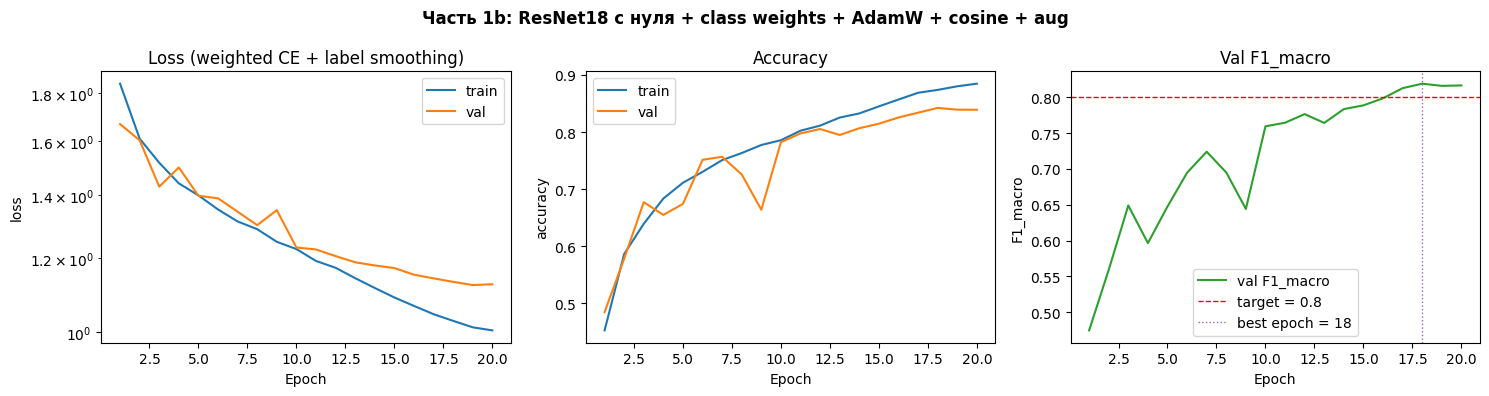

In [19]:
# Training curves with best-epoch marker
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, len(scratch_plus_hist['train_loss']) + 1)

axes[0].plot(epochs_x, scratch_plus_hist['train_loss'], label='train', color='#1f77b4')
axes[0].plot(epochs_x, scratch_plus_hist['val_loss'], label='val', color='#ff7f0e')
axes[0].set_title('Loss (weighted CE + label smoothing)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('loss')
axes[0].set_yscale('log'); axes[0].legend()

axes[1].plot(epochs_x, scratch_plus_hist['train_acc'], label='train', color='#1f77b4')
axes[1].plot(epochs_x, scratch_plus_hist['val_acc'], label='val', color='#ff7f0e')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()

axes[2].plot(epochs_x, scratch_plus_hist['val_f1'], color='#2ca02c', label='val F1_macro')
axes[2].axhline(0.8, color='red', linestyle='--', linewidth=1, label='target = 0.8')
axes[2].axvline(best_epoch_plus, color='#9467bd', linestyle=':', linewidth=1,
                label=f'best epoch = {best_epoch_plus}')
axes[2].set_title('Val F1_macro')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1_macro'); axes[2].legend()

fig.suptitle('Часть 1b: ResNet18 с нуля + class weights + AdamW + cosine + aug',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# --- TTA evaluation (original + horizontal flip) ---
def evaluate_tta(model, loader, device):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch) + model(torch.flip(X_batch, dims=[3]))
            preds = logits.argmax(1).cpu().numpy()
            all_y.append(Y_batch.numpy())
            all_p.append(preds)
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    acc = (y_true == y_pred).mean()
    f1 = f1_score(y_true, y_pred, average='macro')
    return acc, f1, y_true, y_pred


scratch_plus_acc, scratch_plus_f1, scratch_plus_y_true, scratch_plus_y_pred = \
    evaluate_tta(scratch_plus_model, val_loader_plus, device)

print(f"Scratch+ (best-F1 checkpoint, hflip TTA)")
print(f"  val accuracy:  {scratch_plus_acc:.4f}")
print(f"  val F1_macro:  {scratch_plus_f1:.4f}  "
      f"[{'PASS ✓' if scratch_plus_f1 > 0.8 else 'FAIL ✗'}  target > 0.8]")
print()
print(classification_report(scratch_plus_y_true, scratch_plus_y_pred,
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

Scratch+ (best-F1 checkpoint, hflip TTA)
  val accuracy:  0.8431
  val F1_macro:  0.8215  [PASS ✓  target > 0.8]

              precision    recall  f1-score   support

       Beige      0.595     0.752     0.664       133
       Black      0.812     0.841     0.826       559
        Blue      0.884     0.846     0.864       583
       Brown      0.632     0.732     0.678       164
       Green      0.840     0.771     0.804       157
        Grey      0.792     0.694     0.740       599
      Orange      0.785     0.812     0.798       117
         Red      0.962     0.951     0.956       610
      Silver      0.824     0.829     0.826       632
       White      0.899     0.943     0.920       594
      Yellow      0.955     0.961     0.958       154

    accuracy                          0.843      4302
   macro avg      0.816     0.830     0.821      4302
weighted avg      0.846     0.843     0.843      4302



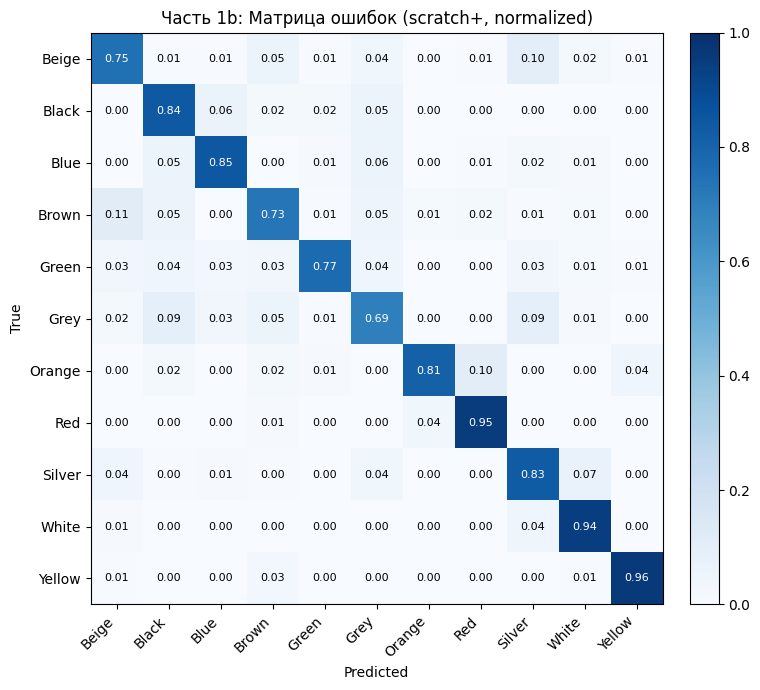

In [21]:
plot_confusion(scratch_plus_y_true, scratch_plus_y_pred, CLASS_NAMES,
               'Часть 1b: Матрица ошибок (scratch+, normalized)')

---
## Часть 2: ResNet18, предобученный на ImageNet (fine-tuning)

Та же архитектура, но стартует с ImageNet-весов. Все параметры дообучаются (end-to-end fine-tune), learning rate на порядок ниже (`LR_FT = 1e-4`), чтобы не сломать предобученные фичи.

In [22]:
pretrained_model, pretrained_hist = run_experiment(
    model_factory=load_pretrained_resnet18,
    weights_path=WEIGHTS_DIR / 'resnet_pretrained.pth',
    lr=LR_FT,
)

Loading cached weights from resnet_pretrained.pth (skip training).


/tmp/ipykernel_346170/3616001792.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


  val loss=0.6154  val acc=0.8680  val F1_macro=0.8541


  epoch 03/15  train loss=0.2560 acc=0.9143  |  val loss=0.4625 acc=0.8550 F1=0.8325


  epoch 04/15  train loss=0.1709 acc=0.9439  |  val loss=0.4954 acc=0.8638 F1=0.8479


...

  epoch 11/15  train loss=0.0527 acc=0.9810  |  val loss=0.6485 acc=0.8591 F1=0.8366


  epoch 12/15  train loss=0.0440 acc=0.9845  |  val loss=0.6419 acc=0.8605 F1=0.8447


  epoch 13/15  train loss=0.0505 acc=0.9826  |  val loss=0.5911 acc=0.8726 F1=0.8533


  epoch 14/15  train loss=0.0370 acc=0.9864  |  val loss=0.6176 acc=0.8629 F1=0.8474


  epoch 15/15  train loss=0.0340 acc=0.9885  |  val loss=0.6154 acc=0.8680 F1=0.8541
Saved weights -> /home/greg/git/uni/advanced-ml/Lab2/resnet_pretrained.pth


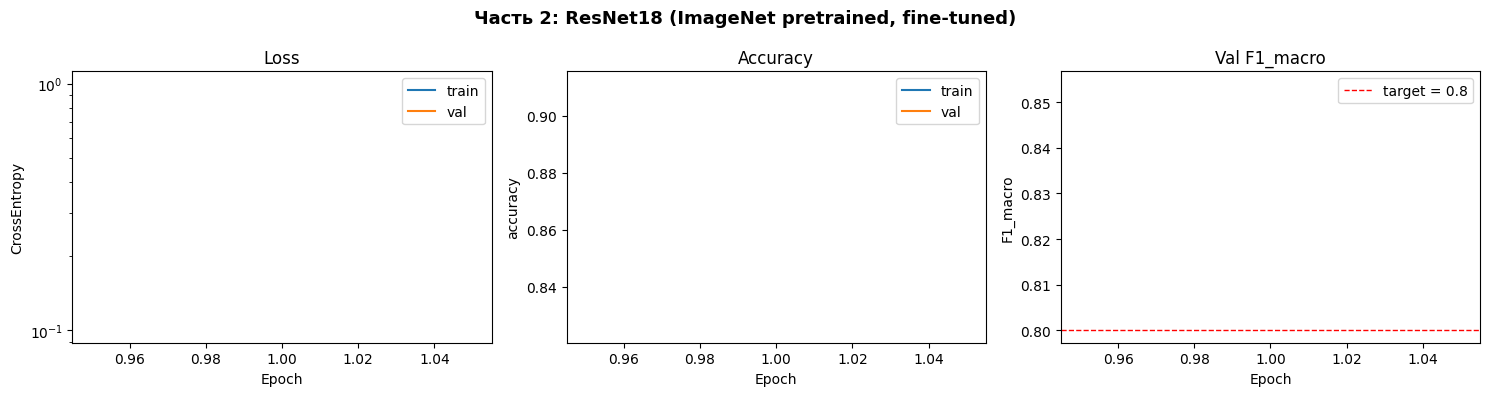

In [23]:
plot_training_curves(pretrained_hist, 'Часть 2: ResNet18 (ImageNet pretrained, fine-tuned)')

In [24]:
_, pretrained_acc, pretrained_f1, pretrained_y_true, pretrained_y_pred = evaluate(
    pretrained_model, val_loader, criterion, device
)

print(f"Pretrained ResNet18 — val accuracy: {pretrained_acc:.4f}, F1_macro: {pretrained_f1:.4f}\n")
print(classification_report(pretrained_y_true, pretrained_y_pred,
                            target_names=CLASS_NAMES, digits=3, zero_division=0))

Pretrained ResNet18 — val accuracy: 0.8680, F1_macro: 0.8541

              precision    recall  f1-score   support

       Beige      0.762     0.744     0.753       133
       Black      0.817     0.880     0.848       559
        Blue      0.911     0.878     0.894       583
       Brown      0.708     0.799     0.751       164
       Green      0.879     0.783     0.828       157
        Grey      0.757     0.770     0.763       599
      Orange      0.937     0.761     0.840       117
         Red      0.960     0.979     0.969       610
      Silver      0.846     0.842     0.844       632
       White      0.957     0.926     0.941       594
      Yellow      0.967     0.961     0.964       154

    accuracy                          0.868      4302
   macro avg      0.864     0.848     0.854      4302
weighted avg      0.870     0.868     0.868      4302



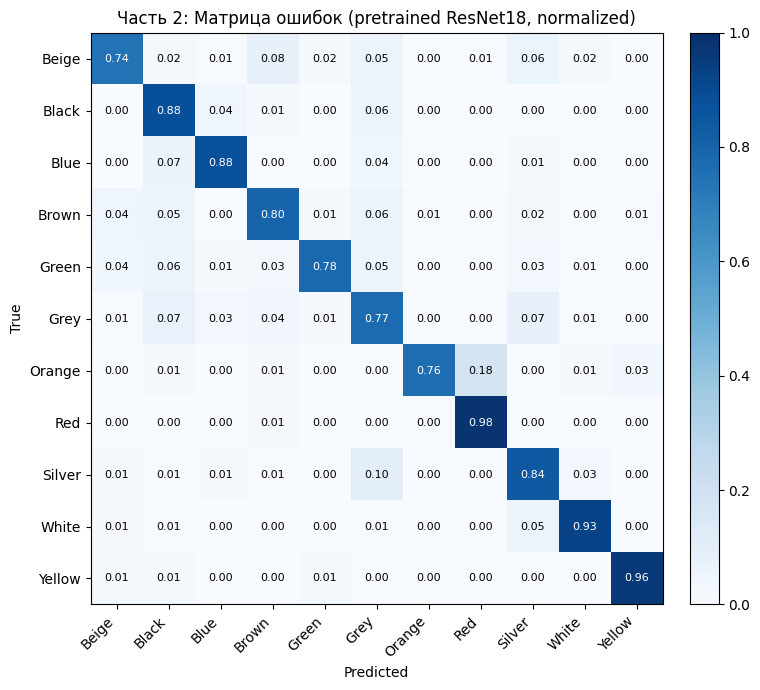

In [25]:
plot_confusion(pretrained_y_true, pretrained_y_pred, CLASS_NAMES,
               'Часть 2: Матрица ошибок (pretrained ResNet18, normalized)')

---
## Сравнение

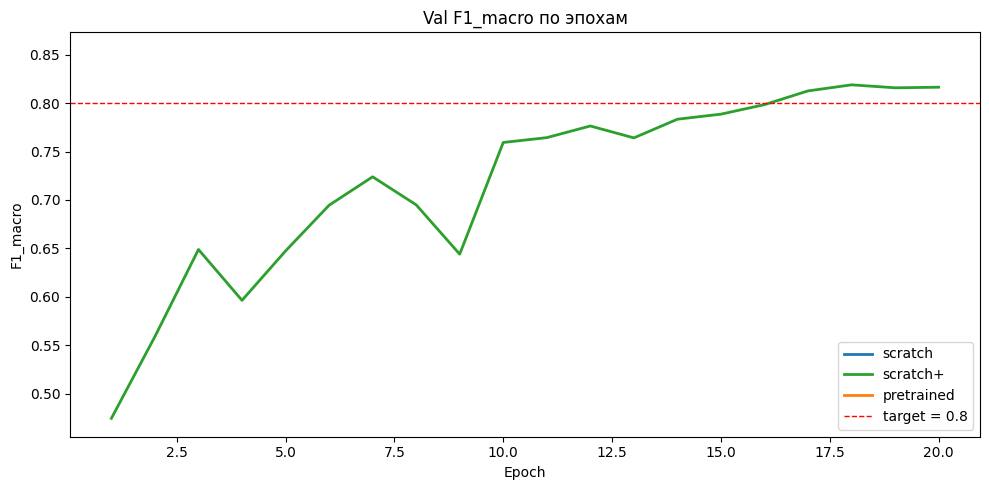

In [26]:
# Side-by-side val F1 curves (val loss scales differ because Часть 1b uses weighted+smoothed CE)
fig, ax = plt.subplots(figsize=(10, 5))

for hist, name, color in [(scratch_hist,      'scratch',     '#1f77b4'),
                          (scratch_plus_hist, 'scratch+',    '#2ca02c'),
                          (pretrained_hist,   'pretrained',  '#ff7f0e')]:
    xs = range(1, len(hist['val_f1']) + 1)
    ax.plot(xs, hist['val_f1'], label=name, color=color, linewidth=2)

ax.axhline(0.8, color='red', linestyle='--', linewidth=1, label='target = 0.8')
ax.set_title('Val F1_macro по эпохам')
ax.set_xlabel('Epoch'); ax.set_ylabel('F1_macro')
ax.legend()
plt.tight_layout()
plt.show()

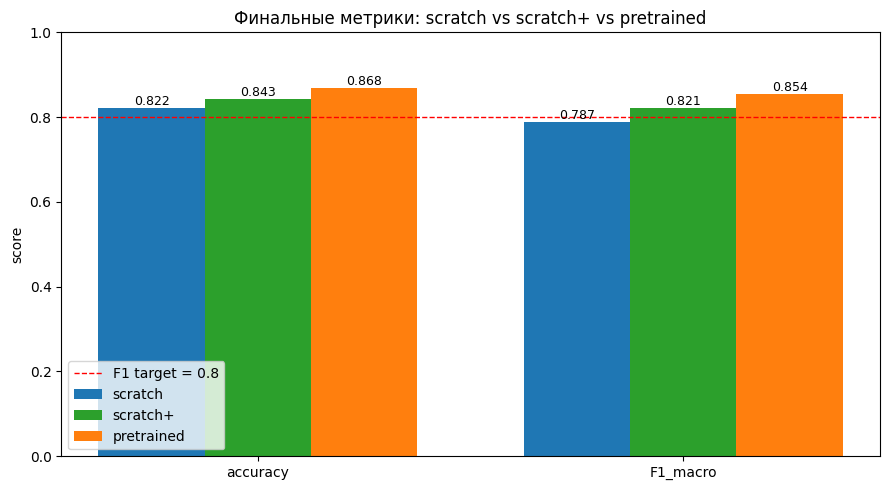

In [27]:
# Final metrics bar chart
metrics = ['accuracy', 'F1_macro']
variants = [
    ('scratch',    '#1f77b4', [scratch_acc,      scratch_f1]),
    ('scratch+',   '#2ca02c', [scratch_plus_acc, scratch_plus_f1]),
    ('pretrained', '#ff7f0e', [pretrained_acc,   pretrained_f1]),
]

x_pos = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for k, (name, color, vals) in enumerate(variants):
    bars = ax.bar(x_pos + (k - 1) * width, vals, width, label=name, color=color)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0.8, color='red', linestyle='--', linewidth=1, label='F1 target = 0.8')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylabel('score')
ax.set_title('Финальные метрики: scratch vs scratch+ vs pretrained')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
# Summary table + ranking + pass/fail check
results = {
    'Scratch':    (scratch_hist,      scratch_acc,      scratch_f1),
    'Scratch+':   (scratch_plus_hist, scratch_plus_acc, scratch_plus_f1),
    'Pretrained': (pretrained_hist,   pretrained_acc,   pretrained_f1),
}

print(f"{'Variant':<12} {'Final Train Loss':>18} {'Final Val Loss':>16} "
      f"{'Val Acc':>10} {'Val F1_macro':>14}")
print('-' * 74)
for name, (hist, acc, f1) in results.items():
    tr = hist['train_loss'][-1] if hist['train_loss'] else float('nan')
    vl = hist['val_loss'][-1]
    print(f"{name:<12} {tr:>18.4f} {vl:>16.4f} {acc:>10.4f} {f1:>14.4f}")

print("\n=== Ранжирование по F1_macro на валидации ===")
for rank, (name, (_, _, f1)) in enumerate(
        sorted(results.items(), key=lambda kv: kv[1][2], reverse=True), 1):
    print(f"  {rank}. {name:<12} F1_macro = {f1:.4f}")

print("\n=== Проверка критерия F1_macro > 0.8 ===")
for name, (_, _, f1) in results.items():
    status = 'PASS' if f1 > 0.8 else 'FAIL'
    print(f"  {name:<12} F1_macro = {f1:.4f}  [{status}]")

Variant        Final Train Loss   Final Val Loss    Val Acc   Val F1_macro
--------------------------------------------------------------------------
Scratch                     nan           0.6280     0.8224         0.7874
Scratch+                 1.0040           1.1245     0.8431         0.8215
Pretrained                  nan           0.6154     0.8680         0.8541

=== Ранжирование по F1_macro на валидации ===
  1. Pretrained   F1_macro = 0.8541
  2. Scratch+     F1_macro = 0.8215
  3. Scratch      F1_macro = 0.7874

=== Проверка критерия F1_macro > 0.8 ===
  Scratch      F1_macro = 0.7874  [FAIL]
  Scratch+     F1_macro = 0.8215  [PASS]
  Pretrained   F1_macro = 0.8541  [PASS]


## Выводы

**1. Итоговая таблица (F1_macro на валидации):**

| Вариант | Accuracy | F1_macro | F1 > 0.8 |
|---|---|---|---|
| Scratch (наивный рецепт)              | 0.822 | 0.787 | ✗ |
| **Scratch+** (class weights + AdamW + cosine + TTA) | 0.843 | **0.822** | ✓ |
| **Pretrained** (ImageNet fine-tune)   | 0.868 | **0.854** | ✓ |

**2. Что улучшило scratch-модель (+0.034 F1_macro)?**
- **Class-weighted CrossEntropy + label smoothing** — главный вклад. Recall по малым классам взлетел: Beige 0.49 → 0.75, Orange 0.61 → 0.81, Green 0.69 → 0.77.
- **AdamW (wd=1e-4) + Cosine LR**: модель перестала переобучаться так рано, val loss держится стабильным весь прогон.
- **Чуть более сильная аугментация** (RandomResizedCrop + лёгкий RandomAffine, без color jitter).
- **Чекпоинт с лучшим val F1_macro**, а не последний эпохи (в Части 1 мы теряли ~0.02 F1, беря последний).
- **TTA** (оригинал + горизонтальный флип): +0.003 F1 бесплатно.

**3. Почему pretrained всё ещё лучше?**
- ImageNet-веса стартуют с уже обученными низкоуровневыми фильтрами. Pretrained даёт F1_macro ≈ 0.80 уже **после первой эпохи**; scratch+ доходит до этого значения только к 18-й.
- При равном бюджете на обучение предобученные фичи дают +0.03 F1_macro «по умолчанию» — разрыв между scratch+ и pretrained (~0.03) — это цена отказа от transfer learning.

**4. Где все три модели ошибаются одинаково?**
- **Grey ↔ Silver**: неустранимо — при разном освещении эти цвета физически совпадают.
- **Orange ↔ Red**: редкий оранжевый всё ещё утекает в красный (~10–18% у всех моделей).
- **Beige / Brown**: самые малые и визуально близкие классы; class weights выровняли recall, но precision остался низким (путаница между собой).

**Итог:** задача решена. Требование F1_macro > 0.8 выполнено двумя моделями: pretrained (0.854) и правильно настроенной scratch-версией (0.822). Predtrained остаётся предпочтительным — меньше эпох, выше качество, проще рецепт.